# Random action agent

In [9]:
import pprint
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 2.5
VM_TYPE1 = 5
VM_TYPE2 = 3
VM_TYPE3 = 1
STEPS = 100
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          alpha = ALPHA,
          beta = BETA)

Check if my custom enivorment correctly follow OpenAI Gym structure

In [3]:
#check_env(env, warn=0, skip_render_check=1)

In [4]:
def run_episode(print_info=False):
    state = env.reset()
    done = False
    score = 0 
    while not done:
        action = env.action_space.sample()
        n_state, reward, done, info = env.step(action)
        
        if print_info:
            pp = pprint.PrettyPrinter(indent=5)
            print("Action: ", action)
            print("Reward: ", reward)
            print("Next state: ", n_state)
            pp.pprint(info)
            print("-----------------------------------------")
        
        score+=reward
    return score

Run single episode and look up detailed information step by step

In [5]:
run_episode(print_info=True)

Action:  5
Reward:  0
Next state:  [40.835]
{    'Current cost': 81.67,
     'Quality of Service': 3.5104,
     'Queue len': 14,
     'Timer': 3.9881973266601562,
     'VM type I': 5,
     'VM type II': 2,
     'VM type III': 1}
-----------------------------------------
Action:  6
Reward:  0
Next state:  [48.7525]
{    'Current cost': 56.67,
     'Quality of Service': 53.0661,
     'Queue len': 13,
     'Timer': 0.24497747421264648,
     'VM type I': 5,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  4
Reward:  0
Next state:  [49.37625]
{    'Current cost': 50.0,
     'Quality of Service': 8.6675,
     'Queue len': 15,
     'Timer': 1.7305958271026611,
     'VM type I': 4,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  0
Reward:  1
Next state:  [49.688126]
{    'Current cost': 50.0,
     'Quality of Service': 60.201,
     'Queue len': 14,
     'Timer': 0.23255443572998047,
     'VM type I':

Action:  0
Reward:  1
Next state:  [98.53381]
{    'Current cost': 96.67,
     'Quality of Service': 7.5271,
     'Queue len': 15,
     'Timer': 1.9928045272827148,
     'VM type I': 11,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  1
Reward:  1
Next state:  [100.93191]
{    'Current cost': 103.33,
     'Quality of Service': 2.8886,
     'Queue len': 12,
     'Timer': 4.154279470443726,
     'VM type I': 12,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  2
Reward:  1
Next state:  [107.96595]
{    'Current cost': 115.0,
     'Quality of Service': 16.5001,
     'Queue len': 13,
     'Timer': 0.7878742218017578,
     'VM type I': 12,
     'VM type II': 3,
     'VM type III': 0}
-----------------------------------------
Action:  0
Reward:  1
Next state:  [111.48298]
{    'Current cost': 115.0,
     'Quality of Service': 3.2113,
     'Queue len': 15,
     'Timer': 4.670987606048584,
     'VM t

Action:  0
Reward:  1
Next state:  [124.62216]
{    'Current cost': 121.67,
     'Quality of Service': 5.3051,
     'Queue len': 15,
     'Timer': 2.8274872303009033,
     'VM type I': 13,
     'VM type II': 3,
     'VM type III': 0}
-----------------------------------------
Action:  5
Reward:  0
Next state:  [117.31108]
{    'Current cost': 110.0,
     'Quality of Service': 3.3146,
     'Queue len': 14,
     'Timer': 4.223674535751343,
     'VM type I': 13,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  1
Reward:  1
Next state:  [116.99054]
{    'Current cost': 116.67,
     'Quality of Service': 4.9029,
     'Queue len': 15,
     'Timer': 3.059401273727417,
     'VM type I': 14,
     'VM type II': 2,
     'VM type III': 0}
-----------------------------------------
Action:  6
Reward:  1
Next state:  [116.83027]
{    'Current cost': 116.67,
     'Quality of Service': 3.0854,
     'Queue len': 14,
     'Timer': 4.537468194961548,
     'VM 

Action:  4
Reward:  0
Next state:  [85.12736]
{    'Current cost': 80.0,
     'Quality of Service': 3.9094,
     'Queue len': 13,
     'Timer': 3.325352191925049,
     'VM type I': 12,
     'VM type II': 0,
     'VM type III': 0}
-----------------------------------------
Action:  0
Reward:  1
Next state:  [82.56368]
{    'Current cost': 80.0,
     'Quality of Service': 3.1257,
     'Queue len': 14,
     'Timer': 4.479004144668579,
     'VM type I': 12,
     'VM type II': 0,
     'VM type III': 0}
-----------------------------------------
Action:  1
Reward:  1
Next state:  [84.61684]
{    'Current cost': 86.67,
     'Quality of Service': 4.2072,
     'Queue len': 14,
     'Timer': 3.3276469707489014,
     'VM type I': 13,
     'VM type II': 0,
     'VM type III': 0}
-----------------------------------------
Action:  4
Reward:  0
Next state:  [82.30842]
{    'Current cost': 80.0,
     'Quality of Service': 7.9349,
     'Queue len': 13,
     'Timer': 1.6383228302001953,
     'VM type I': 

61.5

Run 10 episodes (with no detailed information)

In [6]:
scores = []
episodes = []

for episode in range(1, TEST_EPISODES+1):
    score = run_episode(print_info=False)
    scores.append(score)
    episodes.append(episode)
    print('Episode:{} Score:{}'.format(episode, score))

Episode:1 Score:49.0
Episode:2 Score:57.5
Episode:3 Score:59.5
Episode:4 Score:50.0
Episode:5 Score:54.5
Episode:6 Score:52.0
Episode:7 Score:61.5
Episode:8 Score:53.5
Episode:9 Score:51.5
Episode:10 Score:48.5


Vizualize performce on sample episode

In [7]:
# restart env
obs = env.reset()
done = False

# 
culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []

while True:
    action = env.action_space.sample()
    obs, rewards, done, info = env.step(action)
    
    # save the resuls
    culumative_reward+=rewards
    step +=1
    value.append(culumative_reward)
    steps_lst.append(step)
    quality_of_service.append(info['Quality of Service'])
    utility_function.append(obs)
    cost_lst.append(info['Current cost'])
    no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
    queue_len.append(info['Queue len'])
    
    if done: 
        print('info', info)
        break

info {'Quality of Service': 2.5496, 'Current cost': 96.67, 'Queue len': 13, 'Timer': 5.09891152381897, 'VM type I': 4, 'VM type II': 6, 'VM type III': 0}


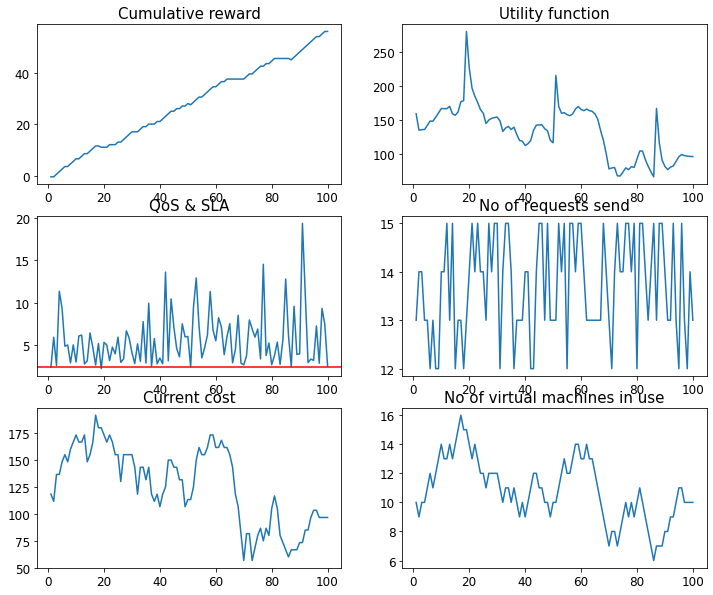

In [8]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)

In [11]:
#print_stats(value, quality_of_service, queue_len, cost_lst,no_of_vm_lst)

In [12]:
# detailed results:
print("Cumulative reward at the end of the test: ", value[-1])
print("Avg cost per step: ", np.round(np.mean(cost_lst), 2))
print("Avg quality of service: ", np.round(np.mean(quality_of_service), 2))
print("Avg no of requests: ", np.mean(queue_len))
print("Avg no of virtual machines: ", np.mean(no_of_vm_lst))

Cumulative reward at the end of the test:  56.0
Avg cost per step:  126.7
Avg quality of service:  5.67
Avg no of requests:  13.72
Avg no of virtual machines:  10.85
